In [225]:
import os
import json
from shapely.geometry import Polygon
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from PIL import Image, ImageDraw, ImageFont
from dotenv import load_dotenv

load_dotenv()
PROJECT_ROOT = os.environ.get("PROJECT_ROOT")
PYTHON_IO_ENCODING = os.environ.get("PYTHON_IO_ENCODING")

In [226]:
output_folder = os.path.join(PROJECT_ROOT, "data", "processed", "segmented_images")
files_folder = os.listdir(output_folder)

Calculate the area per text line box

In [227]:
area_txt_lines = []
for img_segm in files_folder:
    json_path = os.path.join(output_folder, img_segm)
    with open(json_path, "r", encoding="utf-8") as f:
        kraken_output = json.load(f)
    txt_lines = kraken_output.get("lines", [])
    area_txt_lines.append([Polygon(bounds.get("boundary", [])).area for bounds in txt_lines])

Distribution of number of text lines per image

In [228]:
num_txt_lines = [len(lines) for lines in area_txt_lines]
stats = pd.Series(num_txt_lines).describe(percentiles=[0.1, 0.25, 0.75, 0.90])
stats

count     71.000000
mean     196.845070
std       19.059042
min       95.000000
10%      192.000000
25%      196.500000
50%      200.000000
75%      204.000000
90%      208.000000
max      220.000000
dtype: float64

In [ ]:
ind_min_txt_lines = num_txt_lines.index(stats["min"])
print(f"Index of minimum text line count: {ind_min_txt_lines}")
print(f"Corresponding file: {files_folder[ind_min_txt_lines]}")
ind_max_txt_lines = num_txt_lines.index(stats["max"])
print(f"Index of maximum text line count: {ind_max_txt_lines}")
print(f"Corresponding file: {files_folder[ind_max_txt_lines]}")

Index of minimum text line count: 70
Corresponding file: 75_f_070v_garde.json
Index of maximum text line count: 69
Corresponding file: 74_f_069v_070.json


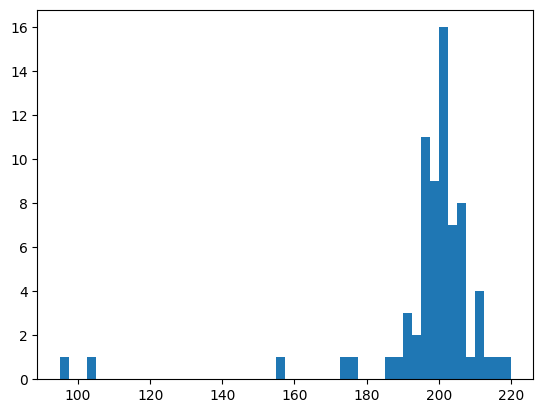

In [ ]:
plt.hist(num_txt_lines,bins=50)
plt.show()

Bound's area distribution overall images

## **Stroke Density Calculation Function**
Ratio between white and black pixels

In [229]:
import cv2 as cv
import numpy as np
import logging
from pathlib import Path
from typing import Union, Tuple, List, Optional
import csv
from tqdm import tqdm

logger = logging.getLogger(__name__)


def calculate_text_density(image: Union[np.ndarray, str, Path]) -> Tuple[float, int, int, int]:
    if isinstance(image, (str, Path)):
        img = cv.imread(str(image), cv.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to load image: {image}")
    else:
        img = image.copy()

    total_pixels = img.size
    height, width = img.shape
    if total_pixels == 0:
        return 0.0

    text_pixels = np.count_nonzero(img == 0)
    return float(text_pixels / total_pixels),total_pixels,height, width

In [230]:
input_img = os.path.join(PROJECT_ROOT, "data", "processed", "binarized_images","05_garde_001","05_garde_001_line_10.png")
calculate_text_density(image=input_img)

(0.25501930501930503, 5180, 37, 140)

In [231]:
input_path = os.path.join(PROJECT_ROOT, "data", "processed", "binarized_images")
input_path = Path(input_path)

image_folders = [f for f in input_path.iterdir() if f.is_dir()]
image_extensions = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
glb_density =[]
for img_folder in tqdm(image_folders, desc="Processing folders", unit="folder"):
    image_files = [f for f in img_folder.iterdir() if f.suffix.lower() in image_extensions]
    folder_density = []
    for img_path in tqdm(image_files, desc=f"Images in {img_folder.name}", unit="file", leave=False):
        try:
            perc =calculate_text_density(image=img_path)
            folder_density.append(perc)
        except Exception as e:
                logger.error(f"Failed to process {img_path}: {e}")
                continue
    glb_density.append({'folder': img_folder.name,'total_lines': len(image_files),'density': folder_density})

Processing folders: 100%|██████████| 71/71 [00:56<00:00,  1.27folder/s]


In [232]:
glb_density

[{'folder': '05_garde_001',
  'total_lines': 104,
  'density': [(0.13, 400, 50, 8),
   (0.4486607142857143, 1792, 56, 32),
   (0.25501930501930503, 5180, 37, 140),
   (0.20894636924537258, 16856, 43, 392),
   (0.2682926829268293, 16400, 41, 400),
   (0.31840726834469013, 21573, 51, 423),
   (0.20152036718301777, 13944, 42, 332),
   (0.2681704260651629, 5586, 38, 147),
   (0.31197422588151064, 5587, 37, 151),
   (0.29201101928374656, 4719, 33, 143),
   (0.23057498057498058, 5148, 36, 143),
   (0.3044294294294294, 7992, 36, 222),
   (0.2242310889443059, 14436, 36, 401),
   (0.2564267812388113, 13965, 35, 399),
   (0.2384737678855326, 13838, 34, 407),
   (0.24680629827688652, 13464, 33, 408),
   (0.2145917001338688, 14940, 45, 332),
   (0.23325062034739455, 13702, 34, 403),
   (0.24552046503266015, 16687, 41, 407),
   (0.2597296494355318, 13464, 34, 396),
   (0.26641891891891895, 14800, 37, 400),
   (0.22529313232830822, 15522, 39, 398),
   (0.2553820448557291, 15561, 39, 399),
   (0.2447

In [ ]:
full_density = [item[0] for sublist in glb_density for item in sublist['density']]
full_size = [item[1] for sublist in glb_density for item in sublist['density']]

In [248]:
print(f'{len(full_density)}')

13976


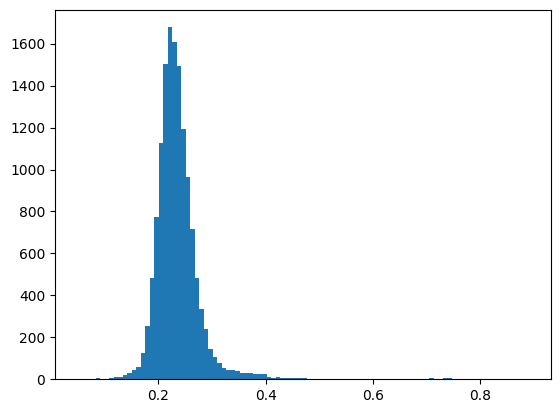

In [ ]:
plt.hist(full_density,bins=100)
plt.show()

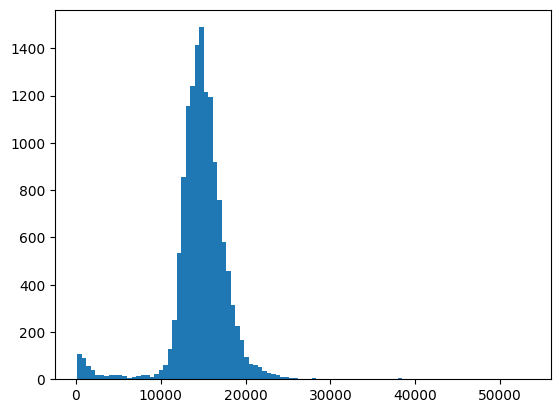

In [ ]:
plt.hist(full_size,bins=100)
plt.show()

In [260]:
stats_density = pd.Series(full_density).describe(percentiles=[0.001,0.002,0.003,0.005,0.01,0.05,0.06,0.07,0.1, 0.25, 0.75,0.9, 0.99,0.995,0.996,0.997,0.998,0.999])
stats_density

count    13976.000000
mean         0.236853
std          0.048808
min          0.049550
0.1%         0.117269
0.2%         0.129934
0.3%         0.139283
0.5%         0.147219
1%           0.160119
5%           0.186770
6%           0.189141
7%           0.191231
10%          0.196775
25%          0.212408
50%          0.230426
75%          0.251624
90%          0.275887
99%          0.399376
99.5%        0.493120
99.6%        0.588358
99.7%        0.646954
99.8%        0.708605
99.9%        0.743727
max          0.889643
dtype: float64

In [ ]:
stats_size = pd.Series(full_size).describe(percentiles=[0.01,0.03,0.04,0.05,0.06,0.07,0.1, 0.25, 0.75,0.9, 0.99,0.995,0.996,0.997,0.998,0.999])
stats_size

count    13976.000000
mean     14799.488409
std       3479.665745
min        174.000000
0.2%       335.600000
1%         859.500000
3%        6631.000000
4%       10426.000000
5%       11163.750000
6%       11592.000000
7%       11850.000000
10%      12307.000000
25%      13464.000000
50%      14800.000000
75%      16338.000000
90%      17952.000000
99%      22706.750000
99.5%    24915.625000
99.6%    26013.600000
99.7%    30921.825000
99.8%    37367.300000
99.9%    41330.175000
max      53340.000000
dtype: float64

In [264]:
bounds_density_p01=[]
bounds_density_p997=[]
bounds_size_p3=[]
bounds_size_p997=[]
large_imgs_15 = []
large_imgs = []
for i, sublist in enumerate(glb_density):
    for j, value in enumerate(sublist['density']):
        path_ = Path(PROJECT_ROOT) / "data" / "processed" / "binarized_images" / sublist['folder']
        image_files = [f for f in path_.iterdir() if f.suffix.lower() in image_extensions]

        if value[0] <= stats_density["0.1%"]:
            bounds_density_p01.append((i, j, image_files[j].stem,value[0],value[1]))

        if value[0] >=  stats_density["99.7%"]:
            bounds_density_p997.append((i, j, image_files[j].stem,value[0],value[1]))

        if value[1] <= stats_size["3%"]:
            bounds_size_p3.append((i, j, image_files[j].stem,value[0],value[1]))

        if value[1] >= stats_size["99.7%"]:
            bounds_size_p997.append((i, j, image_files[j].stem,value[0],value[1]))
        
        if value[2]>(value[3]*1.5):
            large_imgs_15.append((i, j, image_files[j].stem,value[2],value[3]))
        
        if value[2]>value[3]:
            large_imgs.append((i, j, image_files[j].stem,value[2],value[3]))

In [238]:
print(f'Number of long images: {len(large_imgs)}')
print(f'Number of long images: {len(large_imgs_15)}')

Number of long images: 273
Number of long images: 224


In [240]:
diff1 = set(large_imgs).difference(set(large_imgs_15)) 

Filter `glb_density` by `large_imgs`

In [243]:

exclude_indices = {(i, j) for i, j, _, _, _ in large_imgs}

filt_L_img_glb_density = []
for i, folder_data in enumerate(glb_density):
    filtered_density = [img_tuple for j, img_tuple in enumerate(folder_data['density']) if (i, j) not in exclude_indices]
    
    filt_L_img_glb_density.append({
        'folder': folder_data['folder'],
        'total_lines': len(filtered_density), 
        'density': filtered_density
    })

In [246]:
full_density_Limg = [item[0] for sublist in filt_L_img_glb_density for item in sublist['density']]
full_size_Limg = [item[1] for sublist in filt_L_img_glb_density for item in sublist['density']]

In [247]:
len(full_density_Limg)

13703

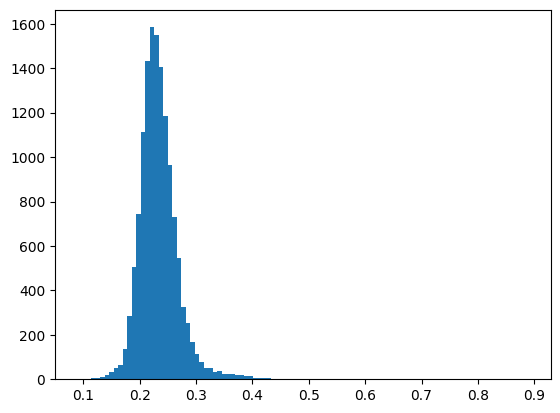

In [249]:
plt.hist(full_density_Limg,bins=100)
plt.show()

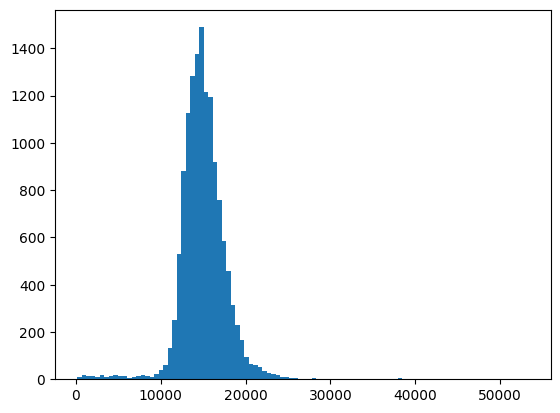

In [250]:
plt.hist(full_size_Limg,bins=100)
plt.show()

In [254]:
stats_density = pd.Series(full_density_Limg).describe(percentiles=[0.001,0.002,0.003,0.005,0.01,0.05,0.06,0.07,0.1, 0.25, 0.75,0.9, 0.99,0.995,0.996,0.997,0.998,0.999])
stats_density

count    13703.000000
mean         0.234553
std          0.040401
min          0.089539
0.1%         0.129821
0.2%         0.139538
0.3%         0.143935
0.5%         0.151121
1%           0.162400
5%           0.186991
6%           0.189441
7%           0.191584
10%          0.196818
25%          0.212249
50%          0.230006
75%          0.250472
90%          0.272622
99%          0.369464
99.5%        0.399639
99.6%        0.410865
99.7%        0.432751
99.8%        0.482860
99.9%        0.701362
max          0.889643
dtype: float64

In [ ]:
stats_size = pd.Series(full_size_Limg).describe(percentiles=[0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.1, 0.25, 0.75,0.9, 0.99])
stats_size

count    13703.000000
mean     15065.546596
std       2938.853891
min        180.000000
1%        5856.540000
2%       10233.040000
3%       11116.120000
4%       11544.960000
5%       11798.500000
6%       12000.000000
7%       12161.120000
10%      12480.000000
25%      13532.000000
50%      14858.000000
75%      16360.000000
90%      17974.000000
99%      22734.000000
99.5%    24938.130000
99.6%    26496.768000
99.7%    31389.474000
99.8%    37490.696000
99.9%    41517.726000
max      53340.000000
dtype: float64

In [259]:
filt_L_img_glb_density

[{'folder': '05_garde_001',
  'total_lines': 100,
  'density': [(0.25501930501930503, 5180, 37, 140),
   (0.20894636924537258, 16856, 43, 392),
   (0.2682926829268293, 16400, 41, 400),
   (0.31840726834469013, 21573, 51, 423),
   (0.20152036718301777, 13944, 42, 332),
   (0.2681704260651629, 5586, 38, 147),
   (0.31197422588151064, 5587, 37, 151),
   (0.29201101928374656, 4719, 33, 143),
   (0.23057498057498058, 5148, 36, 143),
   (0.3044294294294294, 7992, 36, 222),
   (0.2242310889443059, 14436, 36, 401),
   (0.2564267812388113, 13965, 35, 399),
   (0.2384737678855326, 13838, 34, 407),
   (0.24680629827688652, 13464, 33, 408),
   (0.2145917001338688, 14940, 45, 332),
   (0.23325062034739455, 13702, 34, 403),
   (0.24552046503266015, 16687, 41, 407),
   (0.2597296494355318, 13464, 34, 396),
   (0.26641891891891895, 14800, 37, 400),
   (0.22529313232830822, 15522, 39, 398),
   (0.2553820448557291, 15561, 39, 399),
   (0.244786432160804, 15920, 40, 398),
   (0.23867595818815332, 17220, 

In [258]:
bounds_density_p01=[]
bounds_density_p998=[]
bounds_size_p2=[]
for i, sublist in enumerate(filt_L_img_glb_density):
    for j, value in enumerate(sublist['density']):
        path_ = Path(PROJECT_ROOT) / "data" / "processed" / "binarized_images" / sublist['folder']
        image_files = [f for f in path_.iterdir() if f.suffix.lower() in image_extensions]

        if value[0] < stats_density["0.1%"]:
            bounds_density_p01.append((i, j, image_files[j].stem,value[0],value[1]))

        if value[0] >=  stats_density["99.8%"]:
            bounds_density_p998.append((i, j, image_files[j].stem,value[0],value[1]))

        if value[1] <= stats_size["1%"]:
            bounds_size_p2.append((i, j, image_files[j].stem,value[0],value[1]))



In [265]:
print(f"Number of text lines with density <= 0.1%: {len(bounds_density_p01)}")
print(bounds_density_p01[:6])
print(f"Number of text lines with density >= 99.7%: {len(bounds_density_p997)}")
print(bounds_density_p997[:6])

Number of text lines with density <= 0.1%: 14
[(3, 116, '08_f_003v_004_line_202', 0.11666666666666667, 180), (4, 194, '09_f_004v_005_line_93', 0.08791208791208792, 364), (7, 50, '12_f_007v_008_line_143', 0.0873015873015873, 504), (8, 0, '13_f_008v_009_line_0', 0.10416666666666667, 480), (11, 35, '16_f_011v_012_line_13', 0.1135483870967742, 4650), (18, 196, '23_f_018v_019_line_87', 0.08953878406708596, 47700)]
Number of text lines with density >= 99.7%: 42
[(2, 66, '07_f_002v_003_line_158', 0.7326807228915663, 2656), (3, 5, '08_f_003v_004_line_102', 0.7802469135802469, 405), (5, 180, '10_f_005v_006_line_84', 0.7169811320754716, 1166), (7, 117, '12_f_007v_008_line_203', 0.726078799249531, 1066), (7, 192, '12_f_007v_008_line_78', 0.7211538461538461, 2184), (8, 46, '13_f_008v_009_line_14', 0.7326691573266916, 2409)]


In [266]:
print(f"Number of text lines with size <= 3%: {len(bounds_size_p3)}")
print(bounds_size_p3[:6])

Number of text lines with size <= 3%: 682
[(0, 0, '05_garde_001_line_0', 0.13, 400), (0, 1, '05_garde_001_line_1', 0.4486607142857143, 1792), (0, 2, '05_garde_001_line_10', 0.25501930501930503, 5180), (0, 7, '05_garde_001_line_11', 0.2681704260651629, 5586), (0, 8, '05_garde_001_line_12', 0.31197422588151064, 5587), (0, 9, '05_garde_001_line_13', 0.29201101928374656, 4719)]


We filtered out the smallest 5% of the images and additionally filtered based on density values of ≤0.1% and ≥99%.

In [268]:
bounds_density_ = set(bounds_density_p01).union(set(bounds_density_p997))
print(f'{len(bounds_density_p01)},{len(bounds_density_p997)},{len(bounds_density_)}')

14,42,56


In [ ]:
bounds_density_size_ = set(bounds_size_p3).intersection(set(bounds_density_))
img_remove = set([(i,j,stem)for i,j,stem,_,_ in large_imgs]).union(set([(i,j,stem)for i,j,stem,_,_ in bounds_density_size_]))
print(f'{len(bounds_density_size_)},{len(large_imgs)},{len(img_remove)}')

53,273,293


In [286]:
import shutil
from pathlib import Path
from tqdm import tqdm

src_dir = Path(os.path.join(PROJECT_ROOT, "data", "processed", "binarized_images"))
dst_dir = Path(os.path.join(PROJECT_ROOT, "data", "processed", "binarized_images_filtered"))
image_folders = [f for f in src_dir.iterdir() if f.is_dir()]
exclude_keys = {(image_folders[item[0]].stem, item[2]) for item in img_remove}

image_exts = {".jpg", ".jpeg", ".png", ".tif", ".tiff"}
src_files = [f for f in src_dir.rglob("*") if f.is_file() and f.suffix.lower() in image_exts]

copied_count = 0
for src_file in tqdm(src_files, desc="Copying filtered images", unit="file"):
    file_key = (src_file.parent.name, src_file.stem)
    
    folder = 'removed' if file_key in exclude_keys else 'kept'
        
    rel_path = src_file.relative_to(src_dir)
    dst_file = dst_dir /folder / rel_path
    
    dst_file.parent.mkdir(parents=True, exist_ok=True)
    
    shutil.copy2(src_file, dst_file)
    copied_count += 1

print(f"Successfully copied {copied_count} images to:\n  {dst_dir}")

Copying filtered images: 100%|██████████| 13976/13976 [01:17<00:00, 181.31file/s]

Successfully copied 13976 images to:
  D:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\SS2026\Thesis\OCC_HTR\data\processed\binarized_images_filtered
